In [ ]:
import numpy as np

class ReLU:
    def forward(self, x):
        self.x = x
        return np.maximum(0, x)
    def backward(self, grad):
        loc_grad = (self.x > 0).astype(float)
        return grad* loc_grad

class Tanh:
    def forward(self, x):
        self.x = x
        return np.tanh(x)
    def backward(self, grad):
        loc_grad = 1- (np.tanh(self.x)**2)
        return grad * loc_grad

class Sigmoid:
    def forward(self, x):
        self.x = x
        return 1/(1+np.exp(-x))
    def backward(self, grad):
        sigma = 1/(1+np.exp(-self.x))
        loc_grad = sigma*(1-sigma)
        return grad*loc_grad
class Linear:
    def forward(self, x):
        self.x = x
        return x
    def backward(self, grad):
        loc_grad= np.ones_like(self.x)
        return grad*loc_grad
class MSE:
    def forward_loss(self, x, y):
        return np.mean((y-x)**2)
    def backward_loss(self, x, y):
        return (-2*(y-x))/len(x)

class BCE:
    def forward_loss(self, x, y):
        ep = 1e-16
        return -np.mean((y * np.log(x+ep))+((1-y)*np.log(ep+1-x)))
    def backward_loss(self, x, y):
        ep = 1e-16
        return ((x-y)/((x+ep)*(1-x+ep)))/len(y)

class Dense:
    def __init__(self, input_size, output_size):
        self.w = np.random.randn(input_size, output_size) * 0.001 #W (R^input x output) is our weight matrix.
        self.b = np.zeros((1, output_size)) #b (R^1 x output) is our bias vector.
    def forward(self, x):
        self.x = x
        y0 = (x @ self.w)+self.b
        return y0
    def backward(self, dl_by_dy0):
        m = len(self.x)
        self.dl_by_dw = (self.x.T @ dl_by_dy0) / m
        self.dl_by_db = np.sum(dl_by_dy0, axis=0, keepdims=True) / m
        self.dl_by_dx = dl_by_dy0 @ self.w.T
        return self.dl_by_dx
    def step(self, lr):
        self.w = self.w - lr*self.dl_by_dw
        self.b = self.b - lr*self.dl_by_db

# Backward Pass of a Dense Layer

## Forward Equation

For a dense (fully connected) layer:

$$
Y_0 = XW + b
$$

where:

| Variable | Shape | Meaning |
|---|---|---|
| $X$ | $(m,d)$ | input matrix |
| $W$ | $(d,k)$ | weight matrix |
| $b$ | $(1,k)$ | bias vector |
| $Y_0$ | $(m,k)$ | output before activation |

---

## Calculation of the loss function with respect to the y0:
(assuming that the loss function is MSE)
$$
L = \frac{1}{2} (Y - Y0)^2
$$
where Y is the true label of the given data.

# What Does $\frac{\partial L}{\partial Y_0}$ Mean?

$$
\frac{\partial L}{\partial Y_0}
$$

means:

> gradient of the loss $L$ with respect to the layer output $Y_0$

In code:

```python
dl_by_dy0
```

Shape: $(m,k)$

Each element:

$$
\left(\frac{\partial L}{\partial Y_0}\right)_{ij}
=
\frac{\partial L}{\partial y_{ij}}
$$

tells us:

> "If this output changes slightly, how much does the loss change?"

---

# Goal of Backpropagation

We want:

$$
\frac{\partial L}{\partial W},
\quad
\frac{\partial L}{\partial b},
\quad
\frac{\partial L}{\partial X}
$$

---

# 1. Weight Gradient

## Scalar Derivation

For one neuron:

$$
y_j = \sum_i x_i w_{ij} + b_j
$$

Derivative wrt weight:

$$
\frac{\partial y_j}{\partial w_{ij}} = x_i
$$

Apply chain rule:

$$
\frac{\partial L}{\partial w_{ij}}
=
\frac{\partial L}{\partial y_j}
\frac{\partial y_j}{\partial w_{ij}}
$$

Substitute:

$$
\frac{\partial L}{\partial w_{ij}}
=
\frac{\partial L}{\partial y_j} x_i
$$

---

## Matrix Form

For the whole batch:

| Matrix | Shape |
|---|---|
| $X^T$ | $(d,m)$ |
| $dY = \frac{\partial L}{\partial Y_0}$ | $(m,k)$ |

Matrix multiplication:

$$
(d,m) \;@\; (m,k) = (d,k)
$$

which matches weight shape.

Therefore:

$$
\boxed{
\frac{\partial L}{\partial W}
=
X^T \frac{\partial L}{\partial Y_0}
}
$$

If loss is averaged over batch:

$$
\boxed{
\frac{\partial L}{\partial W}
=
\frac{X^T \frac{\partial L}{\partial Y_0}}{m}
}
$$

Code:

```python
self.dl_by_dW = (self.x.T @ dl_by_dy0) / m
```

---

# 2. Bias Gradient

Since:

$$
Y_0 = XW + b
$$

for one neuron:

$$
\frac{\partial y_j}{\partial b_j} = 1
$$

Chain rule:

$$
\frac{\partial L}{\partial b_j}
=
\sum_i
\frac{\partial L}{\partial y_{ij}}
$$

because the same bias is shared across all samples.

So we sum over samples axis.

$$
\boxed{
\frac{\partial L}{\partial b}
=
\sum_{i=1}^{m}
\frac{\partial L}{\partial Y_0}
}
$$

Shape: $(m,k) \rightarrow (1,k)$

If using mean loss:

$$
\boxed{
\frac{\partial L}{\partial b}
=
\frac{
\sum \frac{\partial L}{\partial Y_0}
}{m}
}
$$

Code:

```python
self.dl_by_db = np.sum(dl_by_dy0, axis=0, keepdims=True) / m
```

In [26]:
def singular_neuron(x, y, lr = 0.01, epochs = 50):
    layer1 = Dense(1,1)
    act = Linear()
    loss_fun = MSE()
    history = []
    for t in range(epochs):
        z = layer1.forward(x)
        a = act.forward(z)
        loss = loss_fun(a, y)
        history.append(loss)

        grad = loss_fun.backward_loss(a, y)
        grad = act.backward(grad)
        grad = z.backward(grad)

        layer1.step(lr)
    return layer1, loss

0.005194020322896596


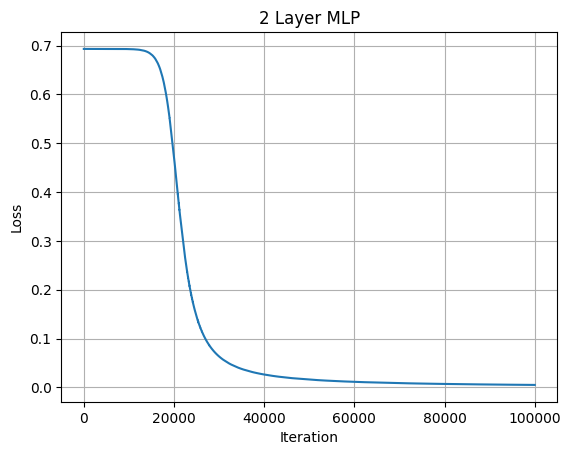

In [24]:
import numpy as np

def simpleMLP(x, y, lr =0.016, epochs=100_000):
    layer1 = Dense(2, 8)
    act1 = ReLU()
    layer2 = Dense(8, 1)
    act2 = Sigmoid()
    loss_fun = BCE()
    history = []
    for t in range(epochs):
        z1 = layer1.forward(x)
        a1 = act1.forward(z1)
        z2 = layer2.forward(a1)
        a2 = act2.forward(z2)
        loss = loss_fun.forward_loss(a2, y)
        history.append(loss)

        grad = loss_fun.backward_loss(a2, y)
        grad = act2.backward(grad)
        grad = layer2.backward(grad)
        grad = act1.backward(grad)
        grad = layer1.backward(grad)

        layer1.step(lr)
        layer2.step(lr)

    return layer1, layer2, history

x = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

d1, d2, history = simpleMLP(x, y)
print(history[-1])
import matplotlib.pyplot as plt
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("2 Layer MLP")
plt.grid(True)
plt.show()

In [25]:
z1 = d1.forward(x)
a1 = ReLU().forward(z1)

z2 = d2.forward(a1)
pred = Sigmoid().forward(z2)

print(pred)

[[0.01411576]
 [0.99809518]
 [0.99809453]
 [0.00274174]]
